# [LAB-10] 2-2. 결과보고 모듈화

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helper import *
from pandas import DataFrame
from IPython.display import Markdown, display

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 및 전처리

1단원과 **동일한 데이터**를 사용한다.

In [2]:
origin = load_data('iris_bin')

# 종속변수 라벨링 (versicolor = 0, virginica = 1)
df = my_prep.labeling(origin, columns=['Species'])

df.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)

Species (2종): versicolor=0, virginica=1


,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,0
1,6.400,3.200,4.500,1.500,0
2,6.900,3.100,4.900,1.500,0
3,5.500,2.300,4.000,1.300,0
4,6.500,2.800,4.600,1.500,0


### 3. 단순 로지스틱 회귀 모형 적합

- 이 결과에서 모형 적합도에 필요한 정보를 추출하고 오즈를 계산해야 한다.

In [3]:
data1 = df[['Sepal_Length', 'Species']]
fit1 = my_logit.fit_model(data1, y='Species', summary=True)

                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        11:16:46   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129      0.465      4.325      0.000       1.101       2.925


## #02. 모듈화 기능 확인

### 1. 모형 적합도

In [4]:
display(Markdown(my_logit.report_fitness(fit1)))

**Note. n =100. LL = -55.273, LL-Null = -69.315, LLR χ² (1) = 28.083, p < 0.001, Pseudo R² =0.203**

Species를 종속변수로, Sepal_Length(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(1) = 28.083, p < 0.001, Pseudo R² = 0.203.

즉, 모형의 유사결정계수는 0.203로 매우 우수한 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다.일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

### 2. 오즈비 보고표

회귀계수·오즈비·95% 신뢰구간·VIF를 하나의 표로 정리한다. (단순모형이라 변수는 하나다.)

In [5]:
my_logit.report_variables(fit1, data1)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Species,Sepal_Length,2.013,1.334,0.465,4.325,0.000,7.485,3.006,18.637,1.000,1.000


### 3. 해석 문장 자동 생성

In [6]:
display(Markdown(my_logit.report_variables_text(fit1, data=data1)))

- **Sepal_Length**의 회귀계수는 **B = 2.0129**, 오즈비는 **OR = 7.4852**로 나타났으며,이는 **Species**에 유의한 요인임을 의미한다. (**z = 4.32**, **p < .001**) 즉, **Sepal_Length**가 1 증가할 때 Species가 1(사건 발생)이 될 오즈는 평균적으로 약 **648.5%****증가**하는 것으로 해석된다.

? ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

### 4. 오즈비 시각화

- 오즈비를 가로 막대로 그린다.
- **OR = 1 기준선**을 넘는지가 핵심이다.

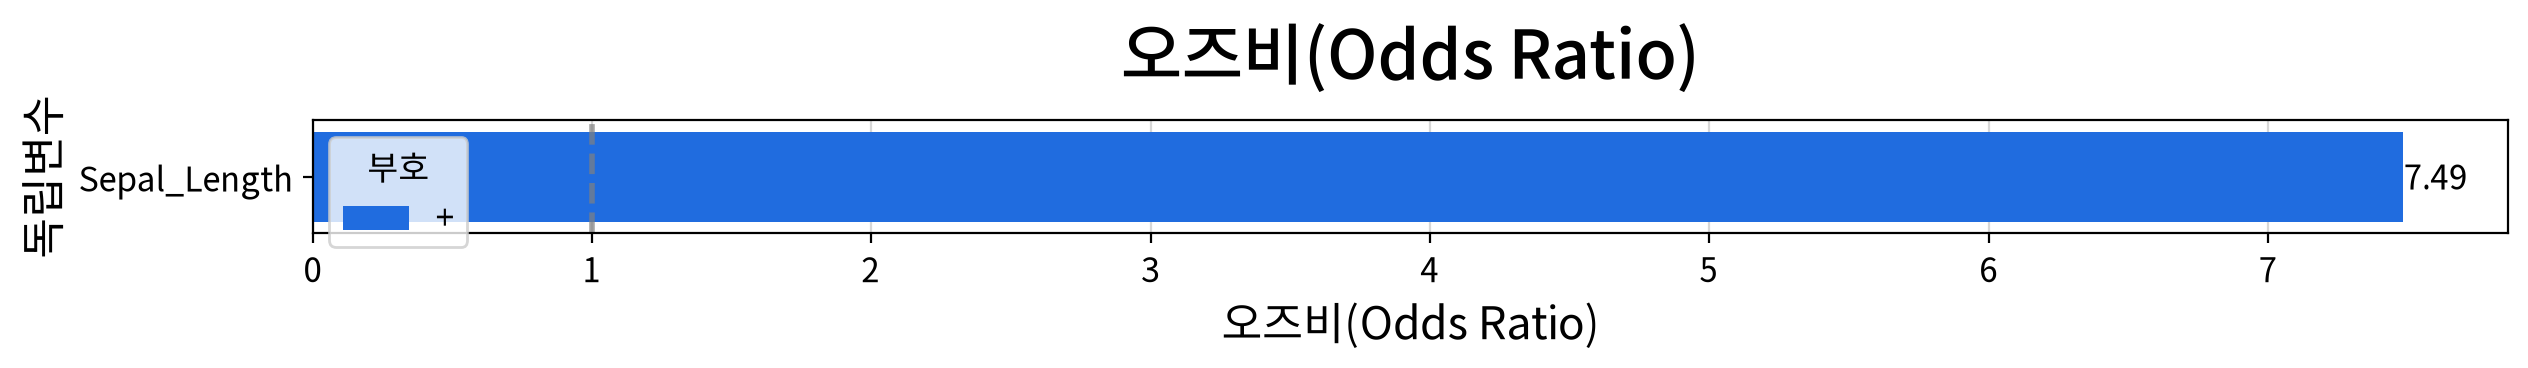

In [7]:
my_logit.plot_odds(fit1, data1, title='오즈비(Odds Ratio)', height=200)

### 연습문제. 혈당 수치로 당뇨 위험도를 설명
#### 문제1. 종속변수 Outcome의 두 범주(0/1)중 관측치가 더 많은 값과 인원수는?
##### 정답 : 0이 500명, 1이 268명으로 0이 더 많다
#### 문제2 . 당뇨 판정 집단(1)의 평균 혈당(Glucose)은 (소수 첫째자리)
##### 141.275이므로 2째자리에서 올림하면 141.3
#### 문제3. 이 모형의 Pseudo Rsquard값은? (소수 셋째자리)
##### 정답 0.272
#### 문제4. Glucose의 오즈비(OR)는 얼마이며, 이를 한 문장으로 어떻게 해석하는가?
##### 정답 Glucose의 회귀계수는 B = 0.0352, 오즈비는 OR = 1.0358로 나타났으며,이는 Outcome에 유의한 요인임을 의미한다. (z = 9.48, p < .001) 즉, Glucose가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 3.6%****증가하는 것으로 해석된다.
#### 문제5. Glucose 오즈비의 95% 신뢰구간은 1을 포함하는가? 그 의미는?
##### 정답 하한1.028,	상한1.043 으로 1을 포함 안한다. 이는 통계적으로 유의미 하다
#### 문제6. 혈당이 10 증가하면 당뇨 오즈는 몇배가 되는가? (소수 둘째자리)
##### 정답 e^10*0.035 = 1.4190675··· 으로 1.42배가 된다.

In [8]:
df = load_data('pima_indians_diabetes')
df1 = my_prep.labeling(df, columns=['Outcome'])
df1

📚 이 데이터 세트는 원래 미국 국립 당뇨병·소화기·신장질환 연구소(National Institute of Diabetes and Digestive and Kidney Diseases)에서 제공한 것입니다. 이 데이터 세트의 목적은 데이터 세트에 포함된 특정 진단 측정값을 기반으로 환자의 당뇨병 여부를 진단적으로 예측하는 것입니다. 더 큰 데이터베이스에서 이러한 사례를 선택하는 데에는 몇 가지 제약 조건이 적용되었습니다. 특히, 여기에 포함된 모든 환자는 21세 이상의 피마 인디언 혈통을 가진 여성입니다. (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

field                     type    description
------------------------  ------  --------------------------------
Pregnancies               연속형  임신횟수
Glucose                   연속형  포도당 부하 검사 수치
BloodPressure             연속형  혈압
SkinThickness             연속형  팔 삼두근 뒤쪽의 피하지방 측정값
Insulin                   연속형  혈청 인슐린
BMI                       연속형  체질량 지수
DiabetesPedigreeFunction  연속형  당뇨 내력 가중치 값
Age                       연속형  나이
Outcome                   명목형  당뇨여부(0 또는 1)

Outcome (2종): 0=0, 1=1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.900,0.171,63,0
764,2,122,70,27,0,36.800,0.340,27,0
765,5,121,72,23,112,26.200,0.245,30,0
766,1,126,60,0,0,30.100,0.349,47,1


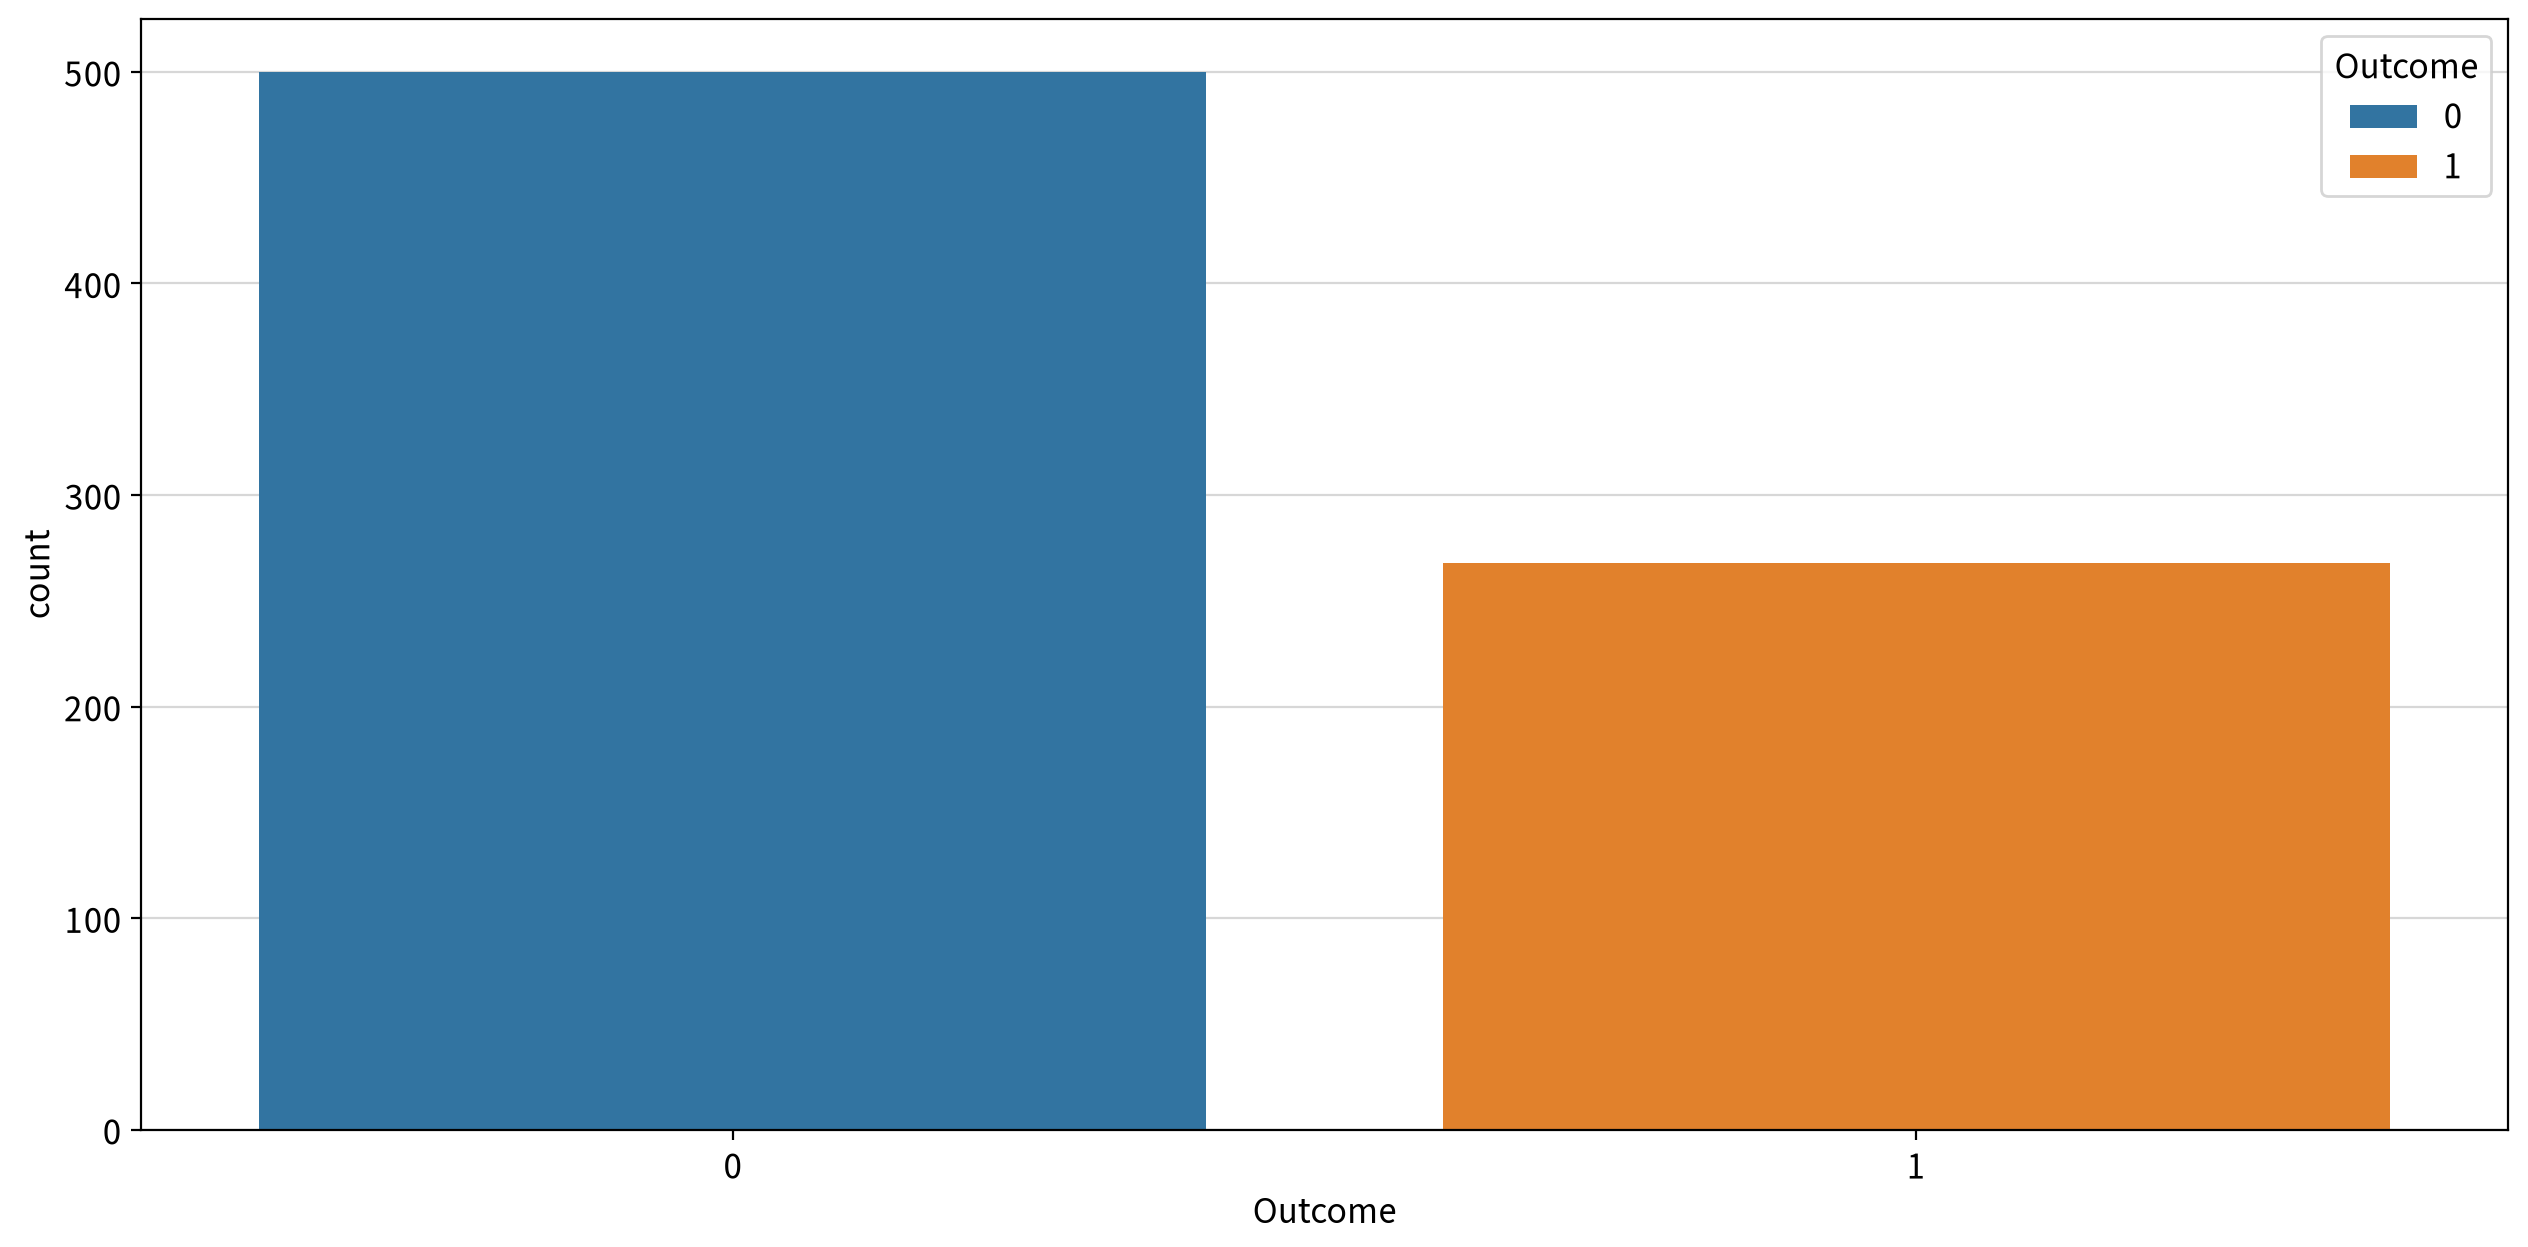

Outcome
0    500
1    268
Name: count, dtype: int64


In [9]:
my_plot.countplot(df1, x='Outcome', hue='Outcome')
print(df1.value_counts('Outcome'))

         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
Outcome                                                                       
False          3.298  109.980         68.184         19.664   68.792 30.304   
True           4.866  141.257         70.825         22.164  100.336 35.143   

         DiabetesPedigreeFunction    Age  Outcome  
Outcome                                            
False                       0.430 31.190    0.000  
True                        0.550 37.067    1.000  


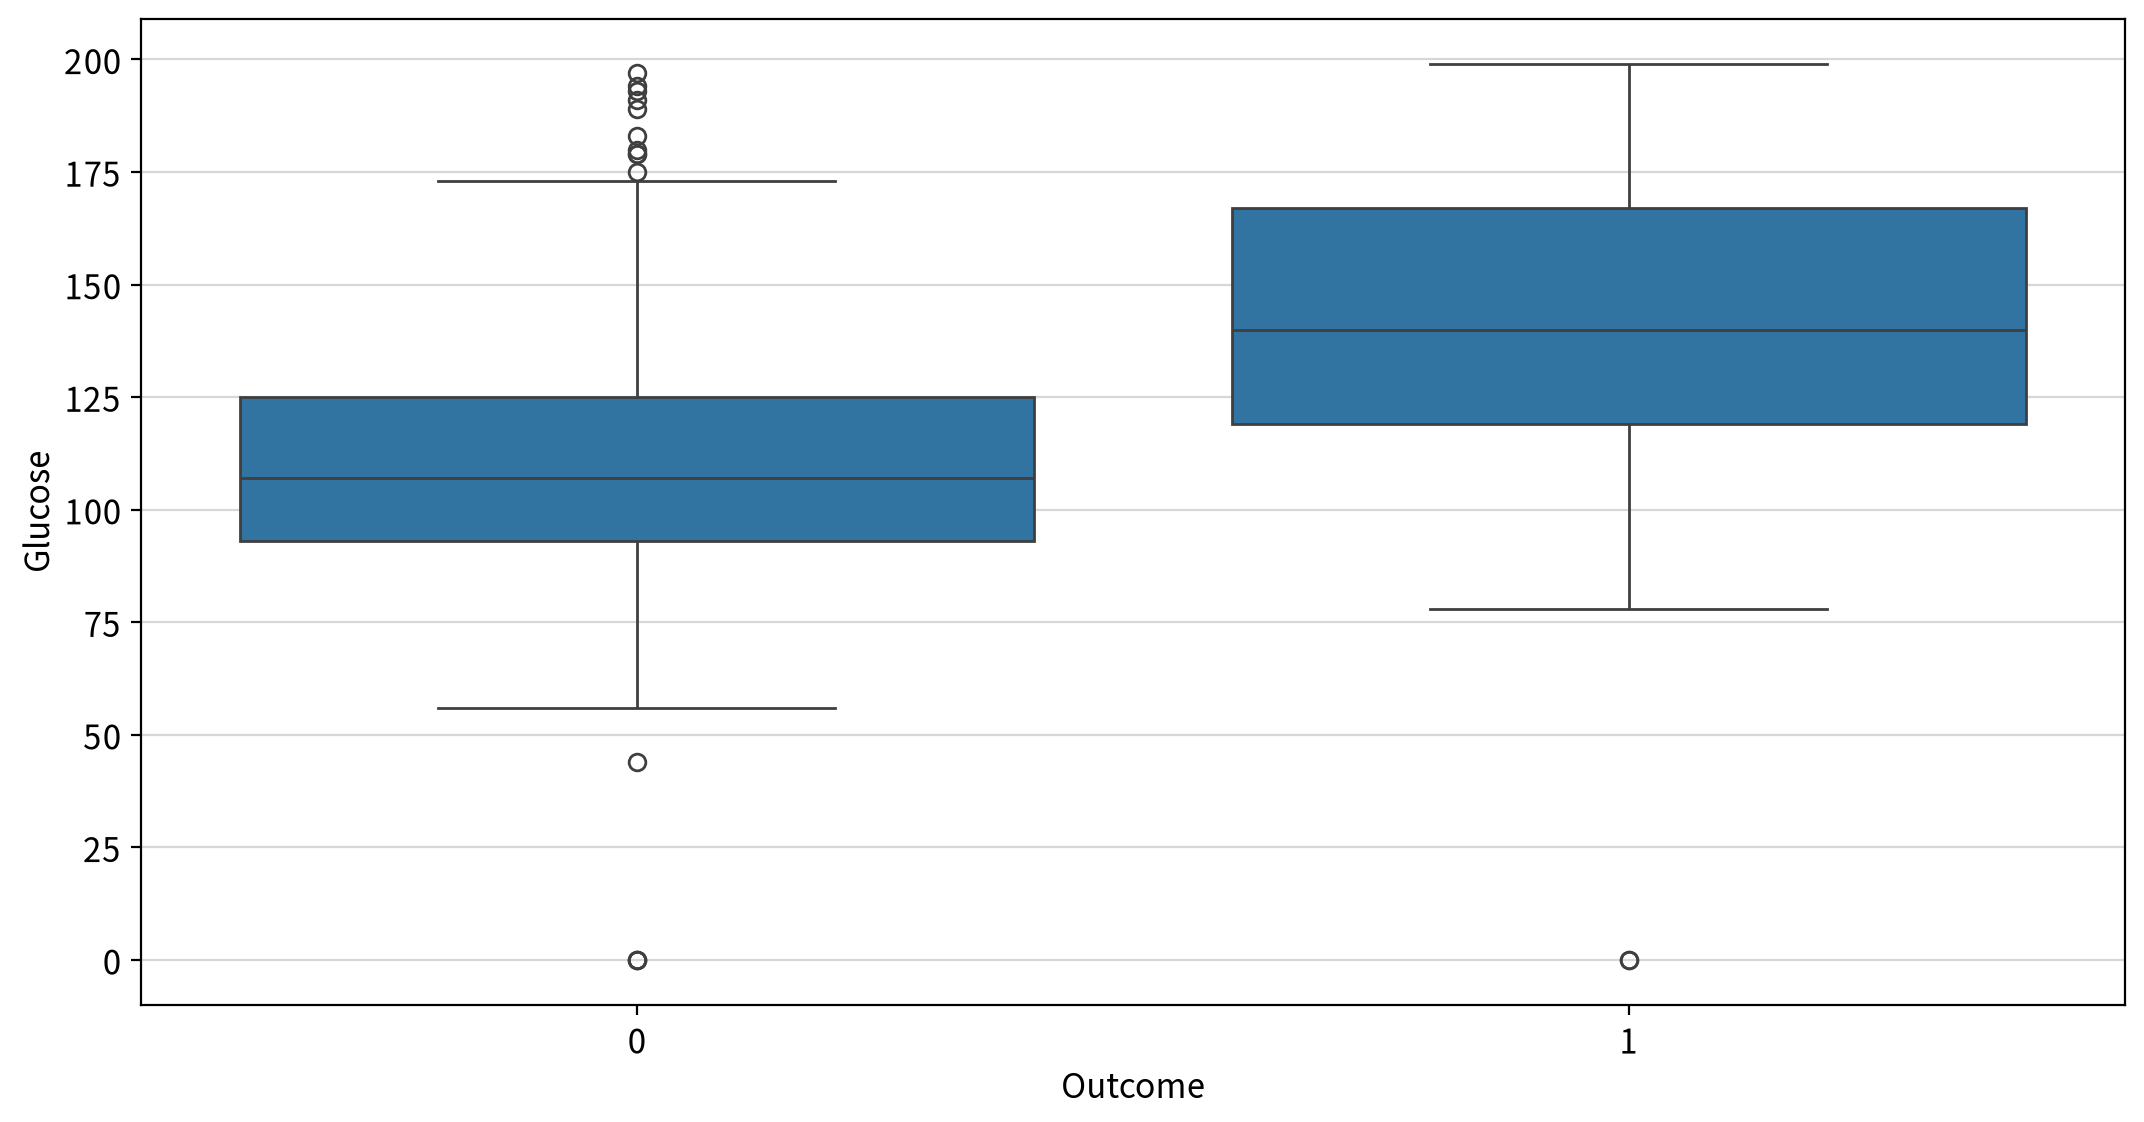

In [10]:
my_plot.boxplot(df1, x='Outcome', y='Glucose')
print(df1.groupby(df1['Outcome'] == 1).mean())

In [11]:
fit1 = my_logit.fit_model(df1,y='Outcome',summary=True)
fit1

                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      759
Method:                           MLE   Df Model:                            8
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.2718
Time:                        11:16:47   Log-Likelihood:                -361.72
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 9.652e-54
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -8.4047      0.717    -11.728      0.000      -9.809      -7.000
Pregnancies                  0.1232      0.032      3.840      0.000       0.060       0.

In [12]:
display(Markdown(my_logit.report_fitness(fit1)))

**Note. n =768. LL = -361.723, LL-Null = -496.742, LLR χ² (8) = 270.039, p < 0.001, Pseudo R² =0.272**

Outcome를 종속변수로, Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(8) = 270.039, p < 0.001, Pseudo R² = 0.272.

즉, 모형의 유사결정계수는 0.272로 매우 우수한 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다.일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

In [13]:
display(Markdown(my_logit.report_variables_text(fit1)))

- **Pregnancies**의 회귀계수는 **B = 0.1232**, 오즈비는 **OR = 1.1311**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 3.84**, **p < .001**) 즉, **Pregnancies**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **13.1%****증가**하는 것으로 해석된다.
- **Glucose**의 회귀계수는 **B = 0.0352**, 오즈비는 **OR = 1.0358**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 9.48**, **p < .001**) 즉, **Glucose**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.6%****증가**하는 것으로 해석된다.
- **BloodPressure**의 회귀계수는 **B = -0.0133**, 오즈비는 **OR = 0.9868**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = -2.54**, **p = .011**) 즉, **BloodPressure**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **1.3%****감소**하는 것으로 해석된다.
- **SkinThickness**의 회귀계수는 **B = 0.0006**, 오즈비는 **OR = 1.0006**로 나타났으며,이는 **Outcome**에 유의하지 않은 요인임을 의미한다. (**z = 0.09**, **p = .929**) 즉, **SkinThickness**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **0.1%****증가**하는 것으로 해석된다.
- **Insulin**의 회귀계수는 **B = -0.0012**, 오즈비는 **OR = 0.9988**로 나타났으며,이는 **Outcome**에 유의하지 않은 요인임을 의미한다. (**z = -1.32**, **p = .186**) 즉, **Insulin**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **0.1%****감소**하는 것으로 해석된다.
- **BMI**의 회귀계수는 **B = 0.0897**, 오즈비는 **OR = 1.0938**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 5.95**, **p < .001**) 즉, **BMI**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **9.4%****증가**하는 것으로 해석된다.
- **DiabetesPedigreeFunction**의 회귀계수는 **B = 0.9452**, 오즈비는 **OR = 2.5733**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 3.16**, **p = .002**) 즉, **DiabetesPedigreeFunction**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **157.3%****증가**하는 것으로 해석된다.
- **Age**의 회귀계수는 **B = 0.0149**, 오즈비는 **OR = 1.015**로 나타났으며,이는 **Outcome**에 유의하지 않은 요인임을 의미한다. (**z = 1.59**, **p = .111**) 즉, **Age**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **1.5%****증가**하는 것으로 해석된다.

? ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

In [14]:
data2 = df1[['Glucose', 'Outcome']]

In [15]:
my_logit.report_variables(fit1, df1)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.945,0.313,0.299,3.160,0.002,2.573,1.432,4.625,0.937,1.067
1,Outcome,Pregnancies,0.123,0.415,0.032,3.840,0.000,1.131,1.062,1.204,0.699,1.431
2,Outcome,BMI,0.090,0.707,0.015,5.945,0.000,1.094,1.062,1.127,0.771,1.297
3,Outcome,Glucose,0.035,1.124,0.004,9.481,0.000,1.036,1.028,1.043,0.770,1.299
4,Outcome,Age,0.015,0.175,0.009,1.593,0.111,1.015,0.997,1.034,0.630,1.588
5,Outcome,BloodPressure,-0.013,-0.257,0.005,-2.540,0.011,0.987,0.977,0.997,0.846,1.182
6,Outcome,Insulin,-0.001,-0.137,0.001,-1.322,0.186,0.999,0.997,1.001,0.701,1.428
7,Outcome,SkinThickness,0.001,0.010,0.007,0.090,0.929,1.001,0.987,1.014,0.663,1.507
